In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os
import optuna
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report, precision_recall_curve, auc, average_precision_score
from sklearn.utils.class_weight import compute_class_weight

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch Version: {torch.__version__}")

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

# Configure plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

PyTorch Version: 2.5.1
Using device: cuda
NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
event_info_df = pd.read_csv("Datasets/Wind Farm A/event_info.csv", sep=";")

In [3]:
# Load data for the identified Gearbox failure events
file_paths = [
    "Datasets/Wind Farm A/datasets/72.csv",
    "Datasets/Wind Farm A/datasets/10.csv",
    "Datasets/Wind Farm A/datasets/51.csv"
]

dfs = [pd.read_csv(path, sep=";") for path in file_paths]
df = pd.concat(dfs, ignore_index=True)

In [4]:
feature_description_df = pd.read_csv("Datasets/Wind Farm A/feature_description.csv", sep=";")

In [5]:
# Features for Drivetrain & Gearbox health
drivetrain_features = [
    'time_stamp', 'asset_id', 
    'sensor_0_avg', 'wind_speed_3_avg', 'power_30_avg', 'sensor_52_avg',
    'sensor_11_avg', 'sensor_12_avg', 'sensor_13_avg', 'sensor_14_avg',
    'sensor_52_std', 'sensor_18_std'
]

df_drivetrain = df[drivetrain_features].copy()

In [6]:
# --- Labeling ---
df_drivetrain['time_stamp'] = pd.to_datetime(df_drivetrain['time_stamp'])
event_info_df['event_start'] = pd.to_datetime(event_info_df['event_start'])
event_info_df['event_end'] = pd.to_datetime(event_info_df['event_end'])

df_drivetrain['label'] = 0
target_keywords = ['Gearbox', 'Bearing', 'Drive'] 

for index, event in event_info_df.iterrows():
    description = str(event['event_description'])
    is_target_failure = any(keyword.lower() in description.lower() for keyword in target_keywords)
    
    if is_target_failure and (event['asset'] in df_drivetrain['asset_id'].unique()):
        # Warning Period: 14 days before failure
        start_warning = event['event_start'] - pd.Timedelta(days=14)
        
        mask = (df_drivetrain['asset_id'] == event['asset']) & \
               (df_drivetrain['time_stamp'] >= start_warning) & \
               (df_drivetrain['time_stamp'] <= event['event_end'])
        
        df_drivetrain.loc[mask, 'label'] = 1

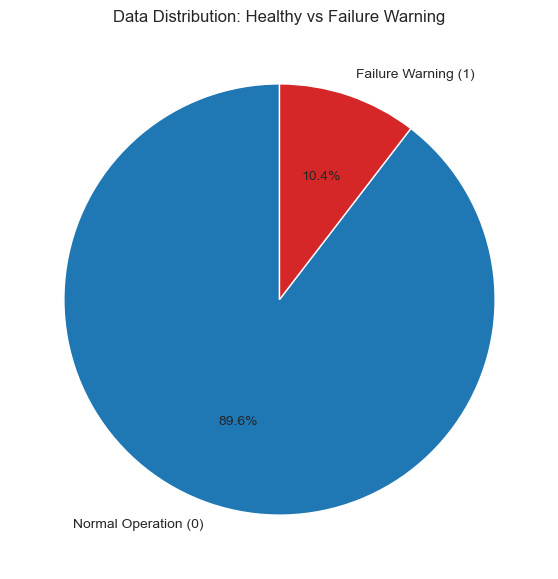

In [7]:
# --- Class Distribution Visualization ---
label_counts = df_drivetrain['label'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(label_counts, labels=['Normal Operation (0)', 'Failure Warning (1)'], autopct='%1.1f%%', colors=['#1f77b4', '#d62728'], startangle=90)
plt.title("Data Distribution: Healthy vs Failure Warning")
plt.show()

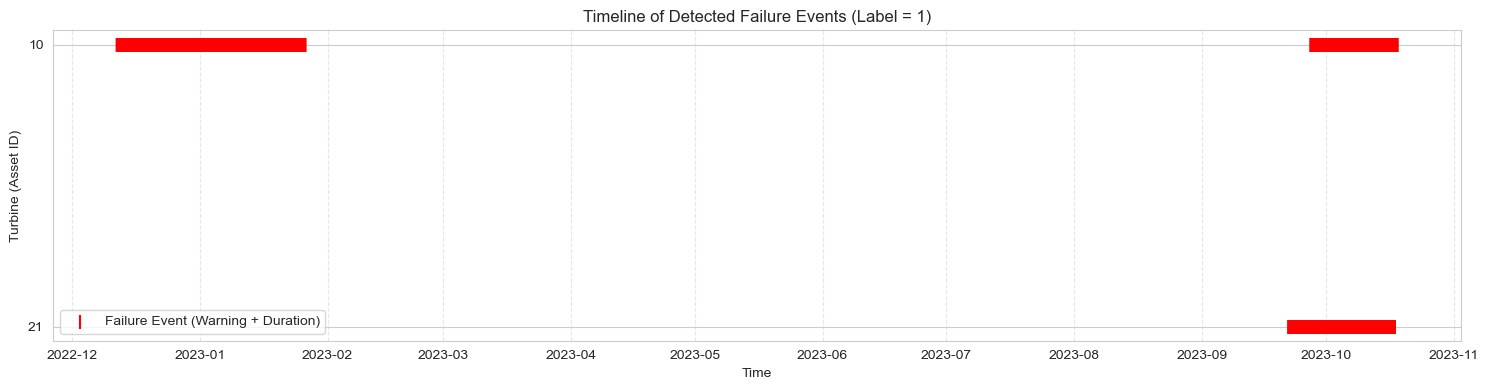

In [8]:
failure_data = df_drivetrain[df_drivetrain['label'] == 1]

plt.figure(figsize=(15, 4))
plt.scatter(failure_data['time_stamp'], failure_data['asset_id'].astype(str), 
            c='red', marker='|', s=100, label='Failure Event (Warning + Duration)')

plt.title("Timeline of Detected Failure Events (Label = 1)")
plt.xlabel("Time")
plt.ylabel("Turbine (Asset ID)")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# --- Train/Test Split with Temporal Gap ---

GAP_DAYS = 14
WINDOW_SIZE = 144

df_drivetrain = df_drivetrain.sort_values(['asset_id', 'time_stamp']).reset_index(drop=True)

split_date = df_drivetrain['time_stamp'].quantile(0.8)
gap_start = split_date - pd.Timedelta(days=GAP_DAYS)
gap_end = split_date + pd.Timedelta(days=GAP_DAYS)

train_raw = df_drivetrain[df_drivetrain['time_stamp'] < gap_start].copy()
test_raw = df_drivetrain[df_drivetrain['time_stamp'] > gap_end].copy()

print(f"Train period: {train_raw['time_stamp'].min()} to {train_raw['time_stamp'].max()}")
print(f"Gap period: {gap_start} to {gap_end}")
print(f"Test period: {test_raw['time_stamp'].min()} to {test_raw['time_stamp'].max()}")
print(f"Train samples: {len(train_raw)}, Test samples: {len(test_raw)}")

Train period: 2022-10-04 01:30:00 to 2023-07-22 22:40:00
Gap period: 2023-07-22 22:42:00 to 2023-08-19 22:42:00
Test period: 2023-08-19 22:50:00 to 2023-10-21 08:40:00
Train samples: 123640, Test samples: 26387


In [10]:
# --- Feature Engineering (Applied Separately to Train/Test) ---

def compute_features(df, window_size):
    sensor_cols = [col for col in df.columns if col not in ['time_stamp', 'asset_id', 'label']]
    
    df_diff = df.groupby('asset_id')[sensor_cols].diff().fillna(0)
    df_diff.columns = [f"{col}_diff" for col in df_diff.columns]
    df = pd.concat([df, df_diff], axis=1)
    
    features_to_roll = [col for col in df.columns if col not in ['time_stamp', 'asset_id', 'label']]
    
    rolling_stats = df.groupby('asset_id')[features_to_roll].rolling(window=window_size).agg(['mean', 'std', 'min', 'max'])
    rolling_stats.columns = [f"{col}_{stat}" for col, stat in rolling_stats.columns]
    rolling_stats = rolling_stats.reset_index(level=0, drop=True)
    
    df_out = df[['time_stamp', 'asset_id']].join(rolling_stats)
    df_out['label'] = df['label']
    df_out = df_out.dropna()
    
    return df_out

train_df = compute_features(train_raw, WINDOW_SIZE)
test_df = compute_features(test_raw, WINDOW_SIZE)

print(f"Train features shape: {train_df.shape}")
print(f"Test features shape: {test_df.shape}")
print(f"Train label distribution:\n{train_df['label'].value_counts()}")
print(f"Test label distribution:\n{test_df['label'].value_counts()}")

Train features shape: (123209, 83)
Test features shape: (26101, 83)
Train label distribution:
label
0    116831
1      6378
Name: count, dtype: int64
Test label distribution:
label
0    15726
1    10375
Name: count, dtype: int64


In [11]:
# --- Data Preparation for Deep Learning ---

def create_sequences(X, y, time_steps=144, step=1):
    X_values = X.astype(np.float32)
    y_values = y.values.astype(np.float32)
    
    num_samples = (len(X) - time_steps) // step
    input_dim = X.shape[1]
    
    Xs = np.zeros((num_samples, time_steps, input_dim), dtype=np.float32)
    ys = np.zeros(num_samples, dtype=np.float32)
    
    for i in range(num_samples):
        start_idx = i * step
        Xs[i] = X_values[start_idx:(start_idx + time_steps)]
        ys[i] = y_values[start_idx + time_steps]
        
    return Xs, ys

feature_cols = [c for c in train_df.columns if c not in ['time_stamp', 'asset_id', 'label']]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[feature_cols]).astype(np.float32)
X_test_scaled = scaler.transform(test_df[feature_cols]).astype(np.float32)

y_train = train_df['label']
y_test = test_df['label']

TIME_STEPS = 144
STEP = 1

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, TIME_STEPS, step=STEP)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, TIME_STEPS, step=STEP)

print(f"Train Shape: {X_train_seq.shape} ({X_train_seq.nbytes / 1e9:.2f} GB)")
print(f"Test Shape: {X_test_seq.shape}")

X_train_tensor = torch.tensor(X_train_seq)
y_train_tensor = torch.tensor(y_train_seq).float()
X_test_tensor = torch.tensor(X_test_seq)
y_test_tensor = torch.tensor(y_test_seq).float()

batch_size = 32

train_data = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size)

test_data = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_data, shuffle=False, batch_size=batch_size)

print(f"Train Label Distribution: {dict(pd.Series(y_train_seq).value_counts())}")
print(f"Test Label Distribution: {dict(pd.Series(y_test_seq).value_counts())}")

Train Shape: (123065, 144, 80) (5.67 GB)
Test Shape: (25957, 144, 80)
Train Label Distribution: {0.0: np.int64(116687), 1.0: np.int64(6378)}
Test Label Distribution: {0.0: np.int64(15582), 1.0: np.int64(10375)}
Train Label Distribution: {0.0: np.int64(116687), 1.0: np.int64(6378)}
Test Label Distribution: {0.0: np.int64(15582), 1.0: np.int64(10375)}


In [17]:
# --- Model 1: LSTM Autoencoder ---

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, seq_len):
        super(LSTMAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        x_repeated = hidden.permute(1, 0, 2).expand(-1, self.seq_len, -1)
        decoded, _ = self.decoder(x_repeated)
        return self.output_layer(decoded)

def train_autoencoder(model, train_loader, epochs=10, learning_rate=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    history_loss = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        history_loss.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}")
        
    return history_loss

In [13]:
# --- Model 2: CNN1D + Attention Classifier ---

class CNN1DAttention(nn.Module):
    def __init__(self, input_dim, seq_len, num_filters=16, kernel_size=3, dropout_rate=0.3):
        super(CNN1DAttention, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=num_filters, kernel_size=kernel_size, padding=1)
        self.relu = nn.ReLU()
        self.att_dense = nn.Linear(num_filters, num_filters)
        self.softmax = nn.Softmax(dim=-1)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(num_filters, 1)

    def attention_block(self, x):
        x_perm = x.permute(0, 2, 1)
        a = self.softmax(self.att_dense(x_perm))
        return (x_perm * a).permute(0, 2, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.attention_block(x)
        x = self.global_avg_pool(x).squeeze(-1)
        x = self.dropout(x)
        return self.classifier(x)

def train_cnn(model, train_loader, epochs=10, learning_rate=0.001, pos_weight=None):
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    history_loss = []
    history_acc = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct += (predicted == targets).sum().item()
            total += targets.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        history_loss.append(epoch_loss)
        history_acc.append(epoch_acc)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}, Acc: {epoch_acc:.4f}")
        
    return history_loss, history_acc

In [14]:
# --- Optuna Hyperparameter Optimization ---

def objective(trial):
    # Hyperparameters to tune
    num_filters = trial.suggest_categorical('num_filters', [16, 32, 64])
    kernel_size = trial.suggest_categorical('kernel_size', [3, 5, 7])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    # Re-create loaders with suggested batch size
    train_loader_opt = DataLoader(train_data, shuffle=True, batch_size=batch_size)
    
    # Initialize model
    input_dim = X_train_seq.shape[2]
    model = CNN1DAttention(input_dim, TIME_STEPS, num_filters, kernel_size, dropout_rate).to(device)
    
    # Class weights for loss
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train_seq), y=y_train_seq)
    pos_weight = torch.tensor([class_weights[1] / class_weights[0]], device=device)

    # Train (fewer epochs for speed during optimization)
    history_loss, history_acc = train_cnn(model, train_loader_opt, epochs=5, learning_rate=learning_rate, pos_weight=pos_weight)
    
    # Evaluation on Test set (using F1 score as metric)
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in DataLoader(test_data, batch_size=batch_size, shuffle=False):
            inputs = inputs.to(device)
            logits = model(inputs)
            preds = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets.numpy())
            
    f1 = f1_score(all_targets, all_preds)
    return f1

print("Starting Optuna Optimization...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) # 10 trials for demonstration/speed

print("Best trial:")
trial = study.best_trial

print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

best_params_cnn = trial.params

[I 2026-01-26 13:45:56,499] A new study created in memory with name: no-name-26c96b31-2e3f-4648-a912-407f47c8ebac


Starting Optuna Optimization...


C:\Users\tibis\AppData\Local\Temp\ipykernel_19404\870850332.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
[I 2026-01-26 13:47:57,286] Trial 0 finished with value: 0.0 and parameters: {'num_filters': 32, 'kernel_size': 3, 'dropout_rate': 0.37930113519147346, 'learning_rate': 0.000254116255280505, 'batch_size': 64}. Best is trial 0 with value: 0.0.
[I 2026-01-26 13:47:57,286] Trial 0 finished with value: 0.0 and parameters: {'num_filters': 32, 'kernel_size': 3, 'dropout_rate': 0.37930113519147346, 'learning_rate': 0.000254116255280505, 'batch_size': 64}. Best is trial 0 with value: 0.0.
C:\Users\tibis\AppData\Local\Temp\ipykernel_19404\870850332.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. 

Best trial:
  Value: 0.0
  Params: 
    num_filters: 32
    kernel_size: 3
    dropout_rate: 0.37930113519147346
    learning_rate: 0.000254116255280505
    batch_size: 64


In [19]:
# --- Experiment: Train Models Multiple Times ---

NUM_RUNS = 2
results = {
    'ae_loss': [],
    'cnn_loss': [],
    'cnn_acc': [],
    'ae_metrics': [],
    'cnn_metrics': [],
    'ae_preds': [],
    'cnn_preds': []
}

input_dim = X_train_seq.shape[2]

# Prepare class weights for CNN
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_seq), y=y_train_seq)
pos_weight = torch.tensor([class_weights[1] / class_weights[0]], device=device)

# Prepare Dataloader for Autoencoder (Traing only on Normal data)
X_train_normal = X_train_tensor[y_train_tensor == 0]
train_normal_loader = DataLoader(TensorDataset(X_train_normal, X_train_normal), shuffle=True, batch_size=32)

print(f"Starting experiment: Training models {NUM_RUNS} times...")
bp = best_params_cnn # Use best parameters from Optuna

for i in range(NUM_RUNS):
    print(f"\n--- Run {i+1}/{NUM_RUNS} ---")
    
    # 1. Train Autoencoder
    print("Training Autoencoder...")
    model_ae = LSTMAutoencoder(input_dim, hidden_dim=32, seq_len=TIME_STEPS).to(device)
    loss_hist_ae = train_autoencoder(model_ae, train_normal_loader, epochs=10)
    results['ae_loss'].append(loss_hist_ae)
    
    # 2. Train CNN
    print("Training CNN...")
    # Helper to get parameter safely
    model_cnn = CNN1DAttention(input_dim, TIME_STEPS, 
                               num_filters=bp['num_filters'], 
                               kernel_size=bp['kernel_size'], 
                               dropout_rate=bp['dropout_rate']).to(device)
    
    train_loader_run = DataLoader(train_data, shuffle=True, batch_size=bp['batch_size'])
    loss_hist_cnn, acc_hist_cnn = train_cnn(model_cnn, train_loader_run, epochs=10, 
                                            learning_rate=bp['learning_rate'], 
                                            pos_weight=pos_weight)
    results['cnn_loss'].append(loss_hist_cnn)
    results['cnn_acc'].append(acc_hist_cnn)
    
    # --- Evaluation for this Run ---
    model_ae.eval()
    model_cnn.eval()

    # AE Evaluation (Batched to avoid OOM)
    ae_mae_list = []
    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            recon = model_ae(inputs)
            batch_mae = torch.mean(torch.abs(inputs - recon), dim=(1, 2))
            ae_mae_list.append(batch_mae.cpu())
    test_mae = torch.cat(ae_mae_list).numpy()
    
    # Simple thresholding for AE (e.g., 95th percentile of construction error on train normal - approximated here or just use optimal for comparison)
    # Using optimal threshold based on test set for metric calculation consistency (as in original nb)
    # Use y_test_seq instead of y_test because of windowing reduction
    prec_ae, rec_ae, thresh_ae = precision_recall_curve(y_test_seq, test_mae)
    f1_ae_curve = np.nan_to_num(2 * prec_ae * rec_ae / (prec_ae + rec_ae))
    best_f1_ae = np.max(f1_ae_curve)
    results['ae_metrics'].append(best_f1_ae)

    # CNN Evaluation
    cnn_probs = []
    with torch.no_grad():
        # Iterate test loader to avoid memory issues if large
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            logits = model_cnn(inputs)
            probs = torch.sigmoid(logits).cpu()
            cnn_probs.append(probs)
    
    cnn_probs = torch.cat(cnn_probs).numpy().flatten()
    
    # Use y_test_seq instead of y_test because of windowing reduction
    prec_cnn, rec_cnn, thresh_cnn = precision_recall_curve(y_test_seq, cnn_probs)
    f1_cnn_curve = np.nan_to_num(2 * prec_cnn * rec_cnn / (prec_cnn + rec_cnn))
    best_f1_cnn = np.max(f1_cnn_curve)
    results['cnn_metrics'].append(best_f1_cnn)
    
    print(f"Run {i+1} Best F1 - Autoencoder: {best_f1_ae:.4f}, CNN: {best_f1_cnn:.4f}")

print("\nExperiment Complete.")

Starting experiment: Training models 2 times...

--- Run 1/2 ---
Training Autoencoder...
Epoch 1/10, Loss: 0.380424
Epoch 1/10, Loss: 0.380424
Epoch 2/10, Loss: 0.264646
Epoch 2/10, Loss: 0.264646
Epoch 3/10, Loss: 0.229012
Epoch 3/10, Loss: 0.229012
Epoch 4/10, Loss: 0.209675
Epoch 4/10, Loss: 0.209675
Epoch 5/10, Loss: 0.193299
Epoch 5/10, Loss: 0.193299
Epoch 6/10, Loss: 0.184403
Epoch 6/10, Loss: 0.184403
Epoch 7/10, Loss: 0.175976
Epoch 7/10, Loss: 0.175976
Epoch 8/10, Loss: 0.168450
Epoch 8/10, Loss: 0.168450
Epoch 9/10, Loss: 0.161813
Epoch 9/10, Loss: 0.161813
Epoch 10/10, Loss: 0.157553
Training CNN...
Epoch 10/10, Loss: 0.157553
Training CNN...


C:\Users\tibis\AppData\Local\Temp\ipykernel_19404\3620072312.py:87: RuntimeWarning: invalid value encountered in divide
  f1_cnn_curve = np.nan_to_num(2 * prec_cnn * rec_cnn / (prec_cnn + rec_cnn))


Run 1 Best F1 - Autoencoder: 0.5727, CNN: 0.5727

--- Run 2/2 ---
Training Autoencoder...
Epoch 1/10, Loss: 0.373241
Epoch 1/10, Loss: 0.373241
Epoch 2/10, Loss: 0.259111
Epoch 2/10, Loss: 0.259111
Epoch 3/10, Loss: 0.224436
Epoch 3/10, Loss: 0.224436
Epoch 4/10, Loss: 0.205386
Epoch 4/10, Loss: 0.205386
Epoch 5/10, Loss: 0.191757
Epoch 5/10, Loss: 0.191757
Epoch 6/10, Loss: 0.182383
Epoch 6/10, Loss: 0.182383
Epoch 7/10, Loss: 0.173801
Epoch 7/10, Loss: 0.173801
Epoch 8/10, Loss: 0.167857
Epoch 8/10, Loss: 0.167857
Epoch 9/10, Loss: 0.162319
Epoch 9/10, Loss: 0.162319
Epoch 10/10, Loss: 0.157837
Training CNN...
Epoch 10/10, Loss: 0.157837
Training CNN...


C:\Users\tibis\AppData\Local\Temp\ipykernel_19404\3620072312.py:69: RuntimeWarning: invalid value encountered in divide
  f1_ae_curve = np.nan_to_num(2 * prec_ae * rec_ae / (prec_ae + rec_ae))


Run 2 Best F1 - Autoencoder: 0.5775, CNN: 0.5711

Experiment Complete.


C:\Users\tibis\AppData\Local\Temp\ipykernel_19404\3620072312.py:87: RuntimeWarning: invalid value encountered in divide
  f1_cnn_curve = np.nan_to_num(2 * prec_cnn * rec_cnn / (prec_cnn + rec_cnn))


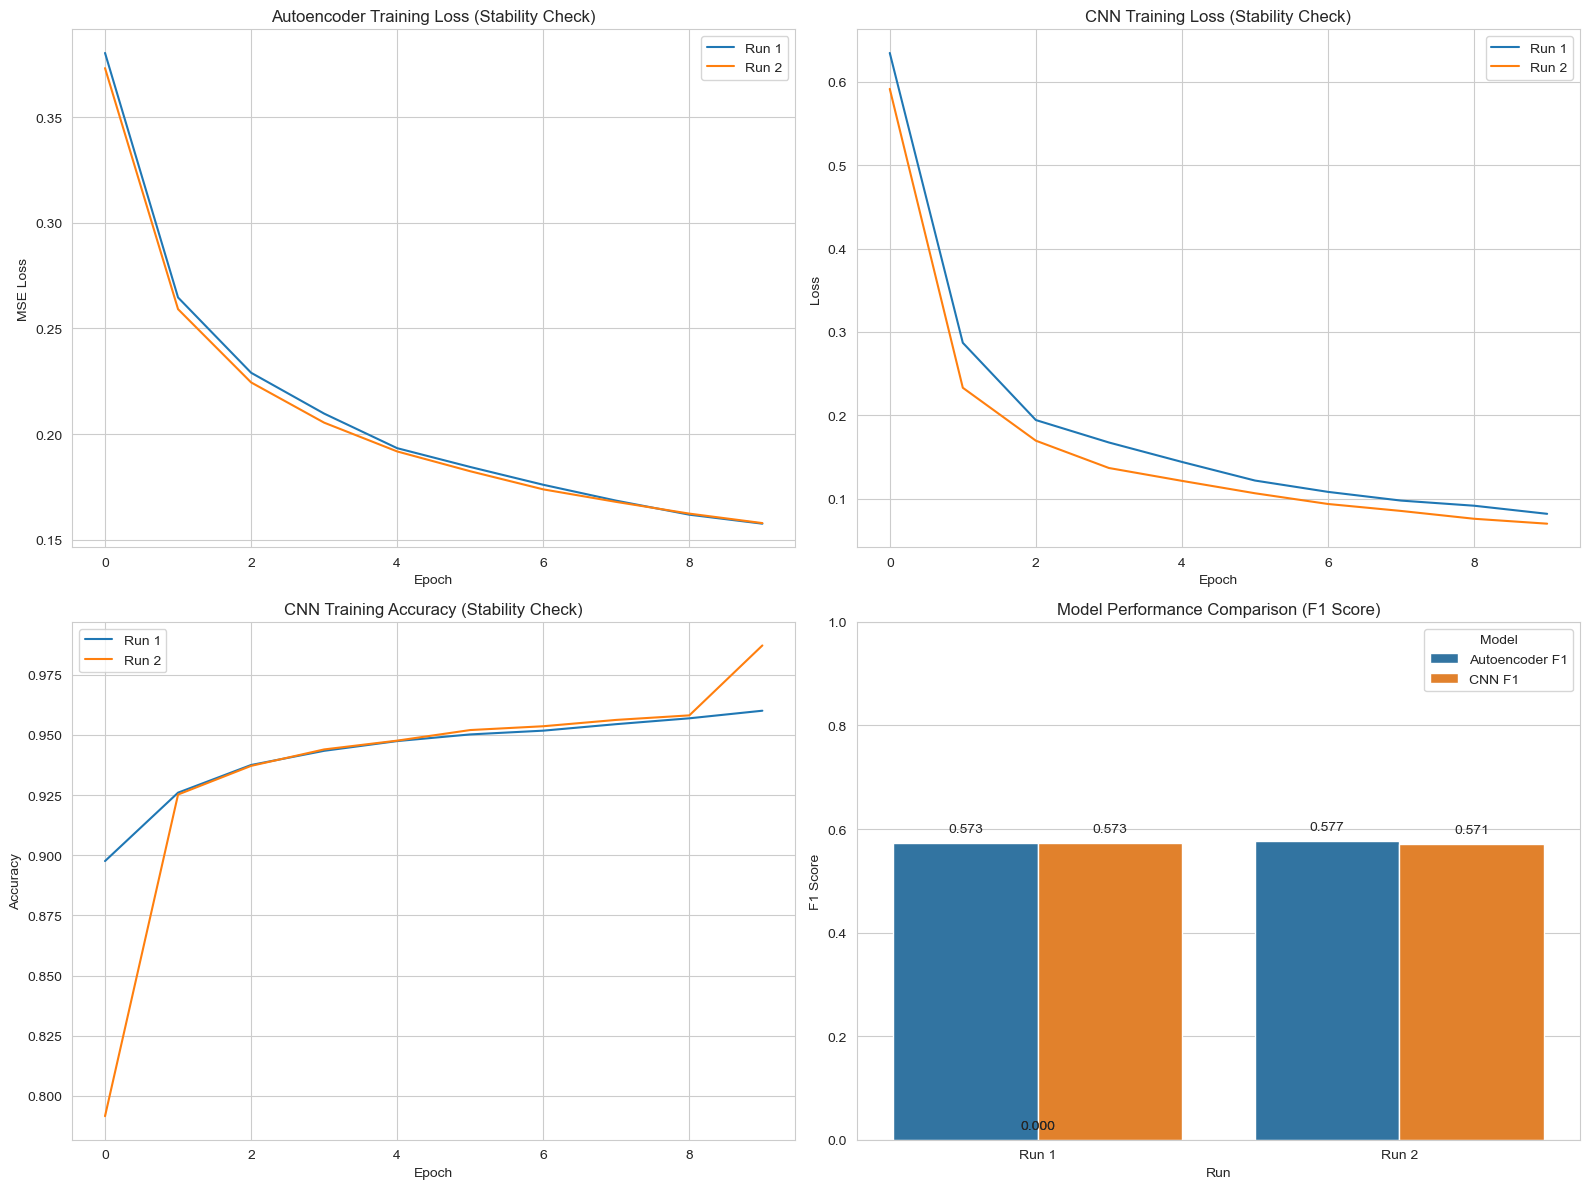


--- Summary Statistics ---
                    mean       std       min       max
Autoencoder F1  0.575074  0.003427  0.572651  0.577497
CNN F1          0.571924  0.001135  0.571122  0.572727


In [20]:
# --- Visualization of Stability & Performance ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Autoencoder Loss Stability
for i, loss in enumerate(results['ae_loss']):
    axes[0, 0].plot(loss, label=f'Run {i+1}')
axes[0, 0].set_title("Autoencoder Training Loss (Stability Check)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("MSE Loss")
axes[0, 0].legend()

# 2. CNN Loss Stability
for i, loss in enumerate(results['cnn_loss']):
    axes[0, 1].plot(loss, label=f'Run {i+1}')
axes[0, 1].set_title("CNN Training Loss (Stability Check)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

# 3. CNN Accuracy Stability
for i, acc in enumerate(results['cnn_acc']):
    axes[1, 0].plot(acc, label=f'Run {i+1}')
axes[1, 0].set_title("CNN Training Accuracy (Stability Check)")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()

# 4. F1 Score Comparison
df_res = pd.DataFrame({
    'Run': [f'Run {i+1}' for i in range(NUM_RUNS)],
    'Autoencoder F1': results['ae_metrics'],
    'CNN F1': results['cnn_metrics']
})

df_res_melted = df_res.melt(id_vars='Run', var_name='Model', value_name='F1 Score')

sns.barplot(data=df_res_melted, x='Run', y='F1 Score', hue='Model', ax=axes[1, 1])
axes[1, 1].set_title("Model Performance Comparison (F1 Score)")
axes[1, 1].set_ylim(0, 1.0)
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\n--- Summary Statistics ---")
print(df_res.describe().transpose()[['mean', 'std', 'min', 'max']])